🔑 Construyendo tensores desde API con filtros razonables y caché…
💾 cache saved (final)
📞 API calls in this run: 0

== TOLERANCE ±0 (local times) ==
Total cost: €1929.87
Start in MAD on 2025-12-23
MAD → CCS | dep 2025-12-23 14:00 CET | arr 2025-12-23 12:30 -04 | dur 3.5h | €499.9
CCS → SCL | dep 2025-12-25 08:10 -04 | arr 2025-12-25 21:30 -03 | dur 12.3h | €372.56
SCL → BER | dep 2025-12-29 10:05 -03 | arr 2025-12-30 11:45 CET | dur 21.7h | €581.33
BER → BEY | dep 2026-01-01 16:25 CET | arr 2026-01-02 01:50 EET | dur 8.4h | €171.88
BEY → BUD | dep 2026-01-03 05:35 EET | arr 2026-01-03 10:25 CET | dur 5.8h | €162.77
BUD → MAD | dep 2026-01-05 18:05 CET | arr 2026-01-06 00:25 CET | dur 6.3h | €141.43

== TOLERANCE ±1 (local times) ==
Total cost: €1715.93
Start in MAD on 2025-12-23
MAD → SCL | dep 2025-12-24 11:50 CET | arr 2025-12-24 21:30 -03 | dur 13.7h | €362.09
SCL → CCS | dep 2025-12-26 22:35 -03 | arr 2025-12-27 06:40 -04 | dur 9.1h | €340.0
CCS → BUD | dep 2025-12-30 10:30 -04 | a

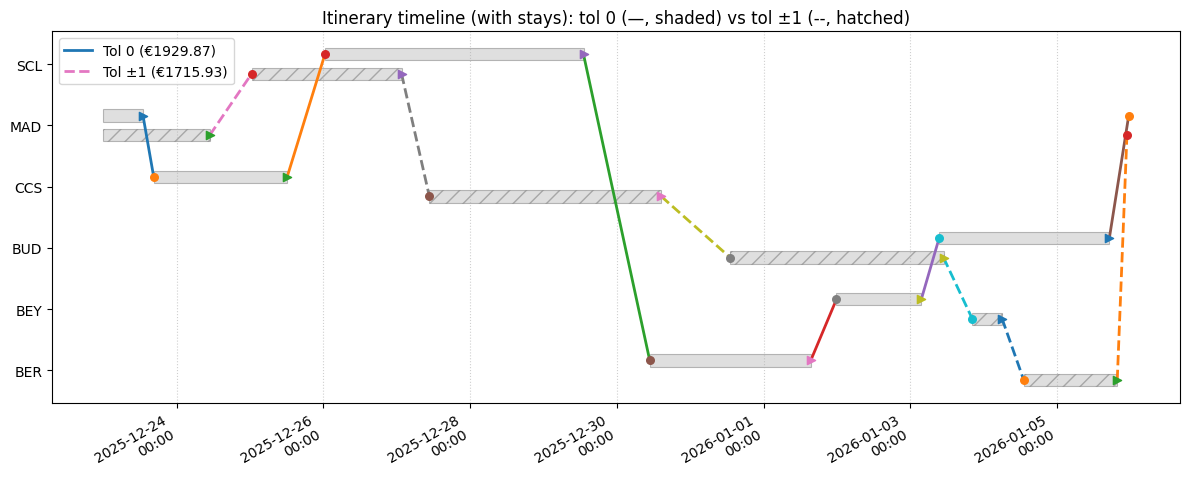

In [ ]:
# ============================================================
# OPTIFLY end-to-end (Amadeus API + filtros + DP + prints + gráfico)
# ============================================================
import os, json, time, math, requests, pathlib
from datetime import date, datetime, timedelta, timezone
from zoneinfo import ZoneInfo
from math import radians, sin, cos, asin, sqrt
from itertools import combinations
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

# -----------------------------
# 0) CONFIGURATION
# -----------------------------
# Amadeus sandbox credentials
AMA_KEY    = os.environ.get("AMA_KEY")
AMA_SECRET = os.environ.get("AMA_SECRET")

# Base Itinerary
cities      = ["MAD", "BUD", "SCL", "CCS", "BEY", "BER"]
start_city  = "MAD"
start_date  = date(2025, 12, 23)
TOTAL_DAYS  = 20
dates       = [start_date + timedelta(days=i) for i in range(TOTAL_DAYS)]


avg_days = {
    "MAD": 0,  # origin
    "BUD": 2,
    "SCL": 3,
    "CCS": 2,
    "BEY": 2,
    "BER": 2,
}
T = len(dates)

# Caché
CACHE_DIR = pathlib.Path("optifly_cache")
CACHE_DIR.mkdir(exist_ok=True)
CACHE_FILE = CACHE_DIR / "amadeus_cache.json"

MAX_CALLS_PER_RUN = 500

# -----------------------------
# 1) MAPS:
# -----------------------------
IATA_TZ = {
    "MAD": "Europe/Madrid",
    "CCS": "America/Caracas",
    "SCL": "America/Santiago",
    "BER": "Europe/Berlin",
    "BEY": "Asia/Beirut",
    "BUD": "Europe/Budapest",
}

IATA_COORDS = {
    "MAD": (40.4722, -3.5608),
    "CCS": (10.6031, -66.9906),
    "SCL": (-33.3929, -70.7858),
    "BER": (52.3667, 13.5033),
    "BEY": (33.8209, 35.4884),
    "BUD": (47.4369, 19.2556),
}

# -----------------------------
# 2) HELPERS:
# -----------------------------
def haversine_km(a, b):
    if a not in IATA_COORDS or b not in IATA_COORDS:
        return None
    lat1, lon1 = IATA_COORDS[a]; lat2, lon2 = IATA_COORDS[b]
    R = 6371.0
    p1, p2 = radians(lat1), radians(lat2)
    dlat = radians(lat2 - lat1); dlon = radians(lon2 - lon1)
    aa = sin(dlat/2)**2 + cos(p1)*cos(p2)*sin(dlon/2)**2
    c = 2*asin(sqrt(aa))
    return R*c

# adaptatives Caps
CRUISE_KMH_SHORT = 780.0;  SLACK_SHORT_H = 2.0;  FACTOR_SHORT = 1.35
CRUISE_KMH_MED   = 780.0;  SLACK_MED_H   = 3.5;  FACTOR_MED   = 1.55
CRUISE_KMH_LONG  = 760.0;  SLACK_LONG_H  = 5.0;  FACTOR_LONG  = 1.75
CRUISE_KMH_ULTRA = 740.0;  SLACK_ULTRA_H = 7.0;  FACTOR_ULTRA = 1.95
MIN_ABS_MINUTES  = 50

def max_duration_hours_adaptive(a, b):
    d = haversine_km(a, b)
    if d is None:
        return float("inf")
    if d <= 1200:      cruise, slack, factor = CRUISE_KMH_SHORT, SLACK_SHORT_H, FACTOR_SHORT
    elif d <= 3000:    cruise, slack, factor = CRUISE_KMH_MED,   SLACK_MED_H,   FACTOR_MED
    elif d <= 7000:    cruise, slack, factor = CRUISE_KMH_LONG,  SLACK_LONG_H,  FACTOR_LONG
    else:              cruise, slack, factor = CRUISE_KMH_ULTRA, SLACK_ULTRA_H, FACTOR_ULTRA
    base_h = d / cruise + slack
    return base_h * factor

# Stops/layovers caps
MAX_STOPS_ALLOWED = 1
MAX_LAYOVER_HOURS = 8.0

# -----------------------------
# 3) TOKEN Amadeus
# -----------------------------
AMADEUS_BASE = "https://test.api.amadeus.com"
_token_cache = {"token": None, "exp_ts": 0}

def get_token_amadeus(client_id, client_secret):
    now = time.time()
    if _token_cache["token"] and now < _token_cache["exp_ts"] - 30:
        return _token_cache["token"]
    url = f"{AMADEUS_BASE}/v1/security/oauth2/token"
    r = requests.post(url, data={"grant_type":"client_credentials",
                                 "client_id":client_id,
                                 "client_secret":client_secret})
    r.raise_for_status()
    tok = r.json()
    _token_cache["token"] = tok["access_token"]
    _token_cache["exp_ts"] = now + int(tok.get("expires_in", 1800))
    return _token_cache["token"]

# -----------------------------
# 4) CACHÉ in disk
# -----------------------------
def load_cache():
    if CACHE_FILE.exists():
        with open(CACHE_FILE, "r") as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f)

def cache_key(origin, dest, yyyy_mm_dd):
    return f"{origin}-{dest}-{yyyy_mm_dd}"

# -----------------------------
# 5) FETCH + FILTER
# -----------------------------
def fromiso(s):  # Amadeus ISO con offset
    return datetime.fromisoformat(s)

def to_utc_naive(dt_with_tz):
    return dt_with_tz.astimezone(timezone.utc).replace(tzinfo=None)

def summarize_offer_reasonable(offer, origin, dest):
    """Devuelve dict con price_total, dep_utc, arr_utc, dur_total_min, stops, razonable?"""
    try:
        price_total = float(offer["price"]["grandTotal"])
    except Exception:
        return {"is_reasonable": False, "reason": "no_price"}

    itins = offer.get("itineraries", [])
    if not itins: return {"is_reasonable": False, "reason": "no_itineraries"}
    segs = itins[0].get("segments", [])
    if not segs: return {"is_reasonable": False, "reason": "no_segments"}

    stops = max(0, len(segs) - 1)

    dep_iso0 = segs[0]["departure"]["at"]
    arr_isoL = segs[-1]["arrival"]["at"]
    dep_dt0  = fromiso(dep_iso0)
    arr_dtL  = fromiso(arr_isoL)
    dep_utc  = to_utc_naive(dep_dt0)
    arr_utc  = to_utc_naive(arr_dtL)
    dur_total_min = int((arr_utc - dep_utc).total_seconds() // 60)

    # Layovers
    max_layover_sec = MAX_LAYOVER_HOURS * 3600
    for i in range(len(segs)-1):
        arr_i  = fromiso(segs[i]["arrival"]["at"])
        dep_i1 = fromiso(segs[i+1]["departure"]["at"])
        lay = (dep_i1 - arr_i).total_seconds()
        if lay < 0:
            return {"is_reasonable": False, "reason": "negative_layover"}
        if lay > max_layover_sec:
            return {"is_reasonable": False, "reason": f"layover_gt_{MAX_LAYOVER_HOURS}h"}

    if stops > MAX_STOPS_ALLOWED:
        return {"is_reasonable": False, "reason": f"stops_gt_{MAX_STOPS_ALLOWED}"}

    if dur_total_min < MIN_ABS_MINUTES:
        return {"is_reasonable": False, "reason": "too_short_abs"}

    max_h = max_duration_hours_adaptive(origin, dest)
    if math.isfinite(max_h) and dur_total_min > int(max_h * 60):
        return {"is_reasonable": False, "reason": f"too_long_cap_{round(max_h,1)}h"}

    return {
        "is_reasonable": True,
        "price_total": price_total,
        "dep_utc": dep_utc,
        "arr_utc": arr_utc,
        "dur_total_min": dur_total_min,
        "stops": stops,
    }

_api_calls_made = 0

def fetch_cheapest_reasonable(origin, dest, yyyy_mm_dd, client_id, client_secret,
                              max_results=50, verbose=False):
    global _api_calls_made
    token = get_token_amadeus(client_id, client_secret)
    url = f"{AMADEUS_BASE}/v2/shopping/flight-offers"
    params = {
        "originLocationCode": origin,
        "destinationLocationCode": dest,
        "departureDate": yyyy_mm_dd,
        "adults": "1",
        "currencyCode": "EUR",
        "max": str(max_results),
        "nonStop": "false",
    }
    headers = {"Authorization": f"Bearer {token}"}
    r = requests.get(url, params=params, headers=headers, timeout=30)
    _api_calls_made += 1
    r.raise_for_status()
    data = r.json()
    offers = data.get("data", []) or []

    filtered = []
    dropped = []
    for off in offers:
        s = summarize_offer_reasonable(off, origin, dest)
        if s.get("is_reasonable"):
            filtered.append((off, s))
        else:
            dropped.append(s.get("reason","?"))

    if verbose:
        print(f"[{origin}->{dest} {yyyy_mm_dd}] offers={len(offers)}, ok={len(filtered)}, drop={len(dropped)}")

    if not filtered:
        return None

    filtered.sort(key=lambda x: float(x[0]["price"]["grandTotal"]))
    best_offer, best_summary = filtered[0]
    return best_offer, best_summary

# -----------------------------
# 6) TENSOR CONSTRUCTION
# -----------------------------
def build_tensors_with_api(cities, dates, client_id, client_secret,
                           use_cache=True, save_every=50, verbose=True):
    # Tensores
    price = {a: {b: [math.inf]*len(dates) for b in cities} for a in cities}
    dep_dt_utc = {a: {b: [None]*len(dates) for b in cities} for a in cities}
    arr_dt_utc = {a: {b: [None]*len(dates) for b in cities} for a in cities}
    dur_m = {a: {b: [None]*len(dates) for b in cities} for a in cities}
    stops = {a: {b: [None]*len(dates) for b in cities} for a in cities}

    cache = load_cache() if use_cache else {}
    calls = 0

    for a in cities:
        for b in cities:
            if a == b:
                continue
            for i, d in enumerate(dates):
                key = cache_key(a, b, d.isoformat())
                if use_cache and key in cache:
                    rec = cache[key]
                    price[a][b][i]     = rec.get("price", math.inf)
                    dur_m[a][b][i]     = rec.get("dur_m")
                    stops[a][b][i]     = rec.get("stops")
                    dep_str            = rec.get("dep_utc")
                    arr_str            = rec.get("arr_utc")
                    dep_dt_utc[a][b][i]= datetime.fromisoformat(dep_str) if dep_str else None
                    arr_dt_utc[a][b][i]= datetime.fromisoformat(arr_str) if arr_str else None
                    continue

                if calls >= MAX_CALLS_PER_RUN:
                    if verbose: print("⛔️ MAX_CALLS_PER_RUN alcanzado.")
                    save_cache(cache)
                    return price, dep_dt_utc, arr_dt_utc, dur_m, stops

                try:
                    res = fetch_cheapest_reasonable(a, b, d.isoformat(),
                                                    client_id, client_secret,
                                                    max_results=50, verbose=False)
                except Exception as e:
                    if verbose: print(f"[API error] {a}->{b} {d}: {e}")
                    res = None

                if res is None:
                    rec = {"price": math.inf, "dur_m": None, "stops": None,
                           "dep_utc": None, "arr_utc": None}
                else:
                    offer, s = res
                    rec = {"price": float(offer["price"]["grandTotal"]),
                           "dur_m": int(s["dur_total_min"]),
                           "stops": int(s["stops"]),
                           "dep_utc": s["dep_utc"].isoformat(),
                           "arr_utc": s["arr_utc"].isoformat()}

                    price[a][b][i]      = rec["price"]
                    dur_m[a][b][i]      = rec["dur_m"]
                    stops[a][b][i]      = rec["stops"]
                    dep_dt_utc[a][b][i] = datetime.fromisoformat(rec["dep_utc"])
                    arr_dt_utc[a][b][i] = datetime.fromisoformat(rec["arr_utc"])

                if use_cache:
                    cache[key] = rec
                    calls += 1
                    if calls % save_every == 0:
                        save_cache(cache)
                        if verbose: print(f"💾 cache saved ({calls} updates)")

    if use_cache:
        save_cache(cache)
        if verbose: print("💾 cache saved (final)")
    return price, dep_dt_utc, arr_dt_utc, dur_m, stops

# -----------------------------
# 7) SOLVER DP (UTC)
# -----------------------------
idx = {c: i for i, c in enumerate(cities)}
rev = {i: c for c, i in idx.items()}

def solve_trip_utc(price, dep_dt_utc, arr_dt_utc, tolerance_value, allow_zero_origin=True):
    local_idx = {c: i for i, c in enumerate(cities)}
    local_rev = {i: c for c, i in local_idx.items()}

    stay_min = {}
    for c in cities:
        base = max(1, avg_days[c] - tolerance_value)
        stay_min[c] = base
    if allow_zero_origin:
        stay_min[start_city] = max(0, avg_days[start_city] - tolerance_value)
    stay_max = {c: min(T, avg_days[c] + tolerance_value) for c in cities}

    dp = {}  # (mask, j, day) -> (cost, prev_tuple)
    def set_dp(mask, j, t, cost, prev):
        key = (mask, j, t)
        if cost < dp.get(key, (math.inf, None))[0]:
            dp[key] = (cost, prev)

    start_idx_i = local_idx[start_city]
    start_mask = 1 << start_idx_i
    set_dp(start_mask, start_idx_i, 0, 0.0, None)

    def day_index_from_dt(dt_utc):
        return (dt_utc.date() - dates[0]).days

    # Transitions
    for mask_size in range(1, len(cities)+1):
        for mask_cities in combinations(range(len(cities)), mask_size):
            mask = sum(1 << j for j in mask_cities)
            if (mask & start_mask) == 0:
                continue
            for j in mask_cities:
                for t in range(T):
                    key = (mask, j, t)
                    if key not in dp:
                        continue
                    curr_cost, _ = dp[key]
                    city_j = local_rev[j]

                    for s in range(stay_min[city_j], stay_max[city_j] + 1):
                        depart_day = t + s
                        if depart_day >= T:
                            continue
                        for k in range(len(cities)):
                            if (mask >> k) & 1:
                                continue
                            city_k = local_rev[k]

                            fc     = price[city_j][city_k][depart_day]
                            dep_dt = dep_dt_utc[city_j][city_k][depart_day]
                            arr_dt = arr_dt_utc[city_j][city_k][depart_day]
                            if fc == math.inf or dep_dt is None or arr_dt is None:
                                continue

                            arr_day = day_index_from_dt(arr_dt)
                            if not (0 <= arr_day < T):
                                continue

                            new_mask = mask | (1 << k)
                            new_t    = arr_day
                            new_cost = curr_cost + fc
                            prev_info = (mask, j, t, city_j, city_k,
                                         depart_day, dep_dt, arr_dt, fc, s)
                            set_dp(new_mask, k, new_t, new_cost, prev_info)

    # Finish at origin
    mask_full = (1 << len(cities)) - 1
    best_cost, best_key, best_close = math.inf, None, None
    for j in range(len(cities)):
        for t in range(T):
            key = (mask_full, j, t)
            if key not in dp:
                continue
            base_cost, _ = dp[key]
            last_city = local_rev[j]
            for s in range(stay_min[last_city], stay_max[last_city] + 1):
                depart_day = t + s
                if depart_day >= T:
                    continue
                fc     = price[last_city][start_city][depart_day]
                dep_dt = dep_dt_utc[last_city][start_city][depart_day]
                arr_dt = arr_dt_utc[last_city][start_city][depart_day]
                if fc == math.inf or dep_dt is None or arr_dt is None:
                    continue
                arr_day = (arr_dt.date() - dates[0]).days
                if not (0 <= arr_day < T):
                    continue
                total = base_cost + fc
                if total < best_cost:
                    best_cost = total
                    best_key  = key
                    best_close= (j, t, s, depart_day, dep_dt, arr_dt, fc)

    # Reconstruction
    itinerary = []
    if best_key is not None:
        key = best_key
        def d2i(dt): return (dt.date() - dates[0]).days
        rev_steps = []
        while key:
            cost, prev = dp[key]
            mask, j, t = key
            city_j = local_rev[j]
            if prev is None:
                rev_steps.append({"arrive_city": city_j,
                                  "arrive_day": t,
                                  "arrive_date": dates[t].isoformat(),
                                  "flight": None,
                                  "added_cost": 0.0})
                break
            (pm, pj, pt, prev_city, curr_city, dep_day, dep_dt, arr_dt, fc, stay_s) = prev
            duration_min = int((arr_dt - dep_dt).total_seconds() // 60)
            rev_steps.append({
                "arrive_city": curr_city,
                "arrive_day": d2i(arr_dt),
                "arrive_date": dates[d2i(arr_dt)].isoformat(),
                "flight": {
                    "from": prev_city, "to": curr_city,
                    "depart_day": dep_day, "depart_date": dates[dep_day].isoformat(),
                    "depart_hour": dep_dt.hour, "depart_min": dep_dt.minute,
                    "arrive_day": d2i(arr_dt), "arrive_hour": arr_dt.hour, "arrive_min": arr_dt.minute,
                    "duration_min": duration_min, "price": fc
                },
                "added_cost": fc
            })
            key = (pm, pj, pt)

        itinerary = list(reversed(rev_steps))
        (lj, lt, ls, r_dep_day, r_dep_dt, r_arr_dt, r_fc) = best_close
        duration_min = int((r_arr_dt - r_dep_dt).total_seconds() // 60)
        last_city = local_rev[lj]
        itinerary.append({
            "arrive_city": start_city,
            "arrive_day": (r_arr_dt.date() - dates[0]).days,
            "arrive_date": dates[(r_arr_dt.date() - dates[0]).days].isoformat(),
            "flight": {
                "from": last_city, "to": start_city,
                "depart_day": r_dep_day, "depart_date": dates[r_dep_day].isoformat(),
                "depart_hour": r_dep_dt.hour, "depart_min": r_dep_dt.minute,
                "arrive_day": (r_arr_dt.date() - dates[0]).days, "arrive_hour": r_arr_dt.hour, "arrive_min": r_arr_dt.minute,
                "duration_min": duration_min, "price": r_fc
            },
            "added_cost": r_fc
        })

    return best_cost, itinerary

# -----------------------------
# 8) PRINTS
# -----------------------------
def print_solution_local(label, cost, itin):
    print(f"\n== {label} (local times) ==")
    if not math.isfinite(cost) or not itin:
        print("No feasible solution.")
        return
    print(f"Total cost: €{round(cost,2)}")
    for step in itin:
        f = step.get("flight")
        if not f:
            print(f"Start in {step['arrive_city']} on {step['arrive_date']}")
            continue
        dep_utc = datetime.combine(dates[f["depart_day"]], datetime.min.time()) + timedelta(
            hours=f["depart_hour"], minutes=f["depart_min"]
        )
        arr_utc = dep_utc + timedelta(minutes=int(f["duration_min"]))
        tz_from = ZoneInfo(IATA_TZ[f["from"]]); tz_to = ZoneInfo(IATA_TZ[f["to"]])
        dep_local = dep_utc.replace(tzinfo=timezone.utc).astimezone(tz_from)
        arr_local = arr_utc.replace(tzinfo=timezone.utc).astimezone(tz_to)
        print(f"{f['from']} → {f['to']} | dep {dep_local.strftime('%Y-%m-%d %H:%M %Z')} | "
              f"arr {arr_local.strftime('%Y-%m-%d %H:%M %Z')} | dur {round(f['duration_min']/60,1)}h | €{f['price']}")

def cost_breakdown(itin, label):
    print(f"\n💸 COST BREAKDOWN — {label}")
    s = 0.0
    for step in itin:
        f = step.get("flight")
        if not f: continue
        s += f["price"]
        print(f"{f['from']}→{f['to']}: €{f['price']} | {f['depart_date']} {f['depart_hour']:02d}:{f['depart_min']:02d}")
    print("TOTAL =", round(s,2), "€")

def stays_by_city(itin):
    flights = []
    for step in itin:
        f = step.get("flight")
        if not f: continue
        dt_dep = datetime.combine(dates[f["depart_day"]], datetime.min.time()) + timedelta(
            hours=f["depart_hour"], minutes=f["depart_min"])
        dt_arr = dt_dep + timedelta(minutes=int(f["duration_min"]))
        flights.append((f["from"], f["to"], dt_dep, dt_arr))
    flights.sort(key=lambda x: x[2])
    cur_city = start_city
    cur_arr = datetime.combine(start_date, datetime.min.time())
    dct = defaultdict(float)
    for (a, b, dt_dep, dt_arr) in flights:
        stay = (dt_dep - cur_arr).total_seconds() / (3600*24)
        if stay > 0: dct[cur_city] += round(stay,2)
        cur_city = b; cur_arr = dt_arr
    return dict(dct)

def flights_for_plot_utc(itin):
    out = []
    for s in itin:
        f = s.get("flight")
        if not f:
            continue
        di = f["depart_day"]
        dt_dep = datetime.combine(dates[di], datetime.min.time()) + timedelta(
            hours=f["depart_hour"], minutes=f["depart_min"]
        )
        dt_arr = dt_dep + timedelta(minutes=int(f["duration_min"]))
        out.append((f["from"], f["to"], dt_dep, dt_arr, f["price"]))
    out.sort(key=lambda x: x[2])
    return out


def itinerary_stays_utc(itin, start_city, start_date):
    fl = flights_for_plot_utc(itin)
    stays = []
    curr_city = start_city
    curr_arr  = datetime.combine(start_date, datetime.min.time())
    for (a,b,dt_dep,dt_arr,_p) in fl:
        if dt_dep > curr_arr:
            stays.append((curr_city, curr_arr, dt_dep))
        curr_city = b; curr_arr = dt_arr
    return stays

def draw_timeline_pair_with_stays(itin_a, label_a, cost_a, itin_b, label_b, cost_b):
    fa = flights_for_plot_utc(itin_a)
    fb = flights_for_plot_utc(itin_b)
    sa = itinerary_stays_utc(itin_a, start_city, start_date)
    sb = itinerary_stays_utc(itin_b, start_city, start_date)

    all_cities = sorted(set([x for leg in (fa + fb) for x in (leg[0], leg[1])]))
    ypos = {c: i for i, c in enumerate(all_cities)}
    fig, ax = plt.subplots(figsize=(12, 5))

    bar_h = 0.20
    off_a = +0.16
    off_b = -0.16

    def draw_stays(stays, off, hatch=None):
        for (city, dt_s, dt_e) in stays:
            if dt_e <= dt_s:
                continue
            x0 = mdates.date2num(dt_s)
            w = mdates.date2num(dt_e) - x0
            y0 = ypos[city] + off - bar_h/2
            rect = Rectangle((x0, y0), w, bar_h, linewidth=0.8,
                             edgecolor="black", facecolor="gray", alpha=0.25, hatch=hatch, zorder=1)
            ax.add_patch(rect)

    draw_stays(sa, off_a, hatch=None)
    draw_stays(sb, off_b, hatch="//")

    def draw_flights(flights, off, style, label):
        lab = label
        for (a, b, dt_dep, dt_arr, pr) in flights:
            x1, x2 = mdates.date2num(dt_dep), mdates.date2num(dt_arr)
            y1, y2 = ypos[a] + off, ypos[b] + off
            ax.plot([x1, x2], [y1, y2], style, lw=2, label=lab, zorder=2)
            lab = "_nolegend_"
            ax.scatter([x1], [y1], marker=">", s=35, zorder=2)
            ax.scatter([x2], [y2], marker="o", s=30, zorder=2)

    draw_flights(fa, off_a, "-",  f"{label_a} (€{round(cost_a,2)})")
    draw_flights(fb, off_b, "--", f"{label_b} (€{round(cost_b,2)})")

    ax.set_yticks(list(ypos.values()))
    ax.set_yticklabels(list(ypos.keys()))
    ax.set_title("Itinerary timeline (with stays): tol 0 (—, shaded) vs tol ±1 (--, hatched)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
    ax.grid(True, axis="x", linestyle=":", alpha=0.6)
    ax.legend(loc="upper left")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


# -----------------------------
# 9) EJECUTION: Build tensors -> Solver -> Prints & Plot
# -----------------------------
print("🔑 Construyendo tensores desde API con filtros razonables y caché…")
price, dep_dt_utc, arr_dt_utc, dur_m, stops = build_tensors_with_api(
    cities, dates, AMA_KEY, AMA_SECRET, use_cache=True, save_every=50, verbose=True
)
print(f"📞 API calls in this run: {_api_calls_made}")

# Ejecute two tolerances (0 y ±1)
cost0, itin0 = solve_trip_utc(price, dep_dt_utc, arr_dt_utc, tolerance_value=0, allow_zero_origin=True)
cost1, itin1 = solve_trip_utc(price, dep_dt_utc, arr_dt_utc, tolerance_value=1, allow_zero_origin=True)

# Prints
print_solution_local("TOLERANCE ±0", cost0, itin0)
print_solution_local("TOLERANCE ±1", cost1, itin1)
if math.isfinite(cost0) and math.isfinite(cost1):
    print(f"\n💰 Savings from flexibility: €{round(cost0 - cost1, 2)}")

cost_breakdown(itin0, "Tol 0")
cost_breakdown(itin1, "Tol ±1")
print("\n🏨 STAYS BY CITY — Tol 0:", stays_by_city(itin0))
print("🏨 STAYS BY CITY — Tol ±1:", stays_by_city(itin1))

# Plot
draw_timeline_pair_with_stays(itin0, "Tol 0", cost0, itin1, "Tol ±1", cost1)


tol=±0: €2011.73  -> OK
tol=±1: €1832.16  -> OK
tol=±2: €1753.0  -> OK


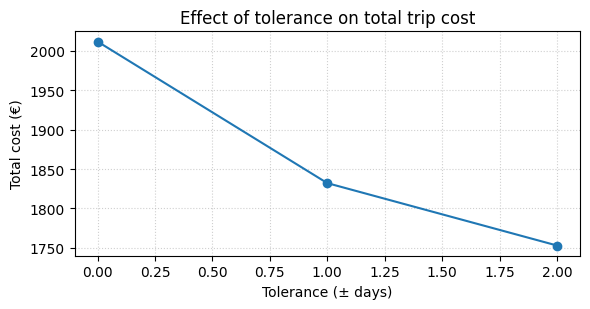

In [ ]:
# ============================
# Sensitivity: cost vs tolerance (±days)
# ============================
import math
import matplotlib.pyplot as plt

def tolerance_sweep(tolerances=(0,1,3), allow_zero_origin=True, verbose=True):
    results = {}
    for tol in tolerances:
        cost, itin = solve_trip_utc(price, dep_dt_utc, arr_dt_utc,
                                    tolerance_value=tol,
                                    allow_zero_origin=allow_zero_origin)
        results[tol] = (cost, itin)
        if verbose:
            status = "OK" if math.isfinite(cost) and itin else "INFEASIBLE"
            print(f"tol=±{tol}: {('€'+str(round(cost,2))) if math.isfinite(cost) else 'inf'}  -> {status}")
    return results

def plot_tolerance(results):
    xs = []
    ys = []
    for tol in sorted(results.keys()):
        cost, itin = results[tol]
        if math.isfinite(cost) and itin:
            xs.append(tol)
            ys.append(cost)
    if not xs:
        print("No feasible solutions to plot.")
        return
    plt.figure(figsize=(6,3.2))
    plt.plot(xs, ys, marker="o")
    plt.title("Effect of tolerance on total trip cost")
    plt.xlabel("Tolerance (± days)")
    plt.ylabel("Total cost (€)")
    plt.grid(True, axis="both", linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

# === Ejecute ===
results = tolerance_sweep(tolerances=(0,1,2), allow_zero_origin=True, verbose=True)
plot_tolerance(results)
